In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf


Mounted at /content/drive


In [ ]:
import pandas as pd

# Replace '/path/to/your/file.pkl' with the actual path to your pickle file in Google Drive
file_path = '/content/drive/MyDrive/assignment/CarPricesData.pkl'

try:
  df = pd.read_pickle(file_path)
  display(df.head())
except FileNotFoundError:
  print(f"Error: The file was not found at {file_path}. Please double-check the path.")
except Exception as e:
  print(f"An error occurred while reading the pickle file: {e}")

,Age,KM,Weight,HP,MetColor,CC,Doors,Price
0,23.0,46986,1165.0,90,1,2000.0,3,13500
1,23.0,72937,1165.0,90,1,2000.0,3,13750
2,24.0,41711,1165.0,90,1,2000.0,3,13950
3,26.0,48000,1165.0,90,0,2000.0,3,14950
4,30.0,38500,1170.0,90,0,2000.0,3,13750


In [ ]:
# Assuming 'Price' is the target variable and the rest are features
feature_columns = df.columns.drop('Price')
X = df[feature_columns]

display(X.head())

,Age,KM,Weight,HP,MetColor,CC,Doors
0,23.0,46986,1165.0,90,1,2000.0,3
1,23.0,72937,1165.0,90,1,2000.0,3
2,24.0,41711,1165.0,90,1,2000.0,3
3,26.0,48000,1165.0,90,0,2000.0,3
4,30.0,38500,1170.0,90,0,2000.0,3


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the features and transform the data
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to a pandas DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)



display(X_scaled_df.head())

,Age,KM,Weight,HP,MetColor,CC,Doors
0,-1.782701,-0.575958,1.957969,-0.767351,0.694578,2.320622,-1.084443
1,-1.782701,0.116474,1.957969,-0.767351,0.694578,2.320622,-1.084443
2,-1.728724,-0.716707,1.957969,-0.767351,0.694578,2.320622,-1.084443
3,-1.620770,-0.548902,1.957969,-0.767351,-1.439724,2.320622,-1.084443
4,-1.404863,-0.802384,2.062852,-0.767351,-1.439724,2.320622,-1.084443


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assuming 'Price' is the target variable
y = df['Price']

# Reshape y to be 2-dimensional before scaling
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

# Split the scaled features and the target variable into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y_scaled, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1004, 7)
Shape of X_test: (431, 7)
Shape of y_train: (1004, 1)
Shape of y_test: (431, 1)


In [ ]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(X_train.shape[1],)), # Corrected Input layer shape
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dense(5, activation='tanh'), # Corrected activation function
        tf.keras.layers.Dense(1, activation='linear') # Corrected activation function
    ],
    name="my_sequential_model"
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
model.compile(optimizer='adam',
              loss='mean_squared_error', # Corrected loss function string
              metrics=['mae']) # Changed accuracy to mae

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if no improvement for 5 epochs
    min_delta=0.001,      # Minimum change to qualify as improvement
    mode='min',          # Minimize the validation loss
    restore_best_weights=True,  # Restore best weights upon stopping
    verbose=1            # Display messages when stopping
)

history = model.fit(X_train, y_train,
                    epochs=50, # Set a high number of epochs, EarlyStopping will stop it early
                    batch_size=20,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping]) # Add the early stopping callback

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1241 - mae: 0.2576 - val_loss: 0.1650 - val_mae: 0.2776
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1163 - mae: 0.2568 - val_loss: 0.1632 - val_mae: 0.2761
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1017 - mae: 0.2411 - val_loss: 0.1642 - val_mae: 0.2770
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1122 - mae: 0.2445 - val_loss: 0.1612 - val_mae: 0.2746
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1098 - mae: 0.2472 - val_loss: 0.1603 - val_mae: 0.2741
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1158 - mae: 0.2559 - val_loss: 0.1594 - val_mae: 0.2741
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1181 - mae: 0.2581 - val_loss: 0.1586 - val_mae: 0.2728
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1300 - mae: 0.2555 - val_loss: 0.1579 - val_mae: 0.2721
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0984 - mae: 

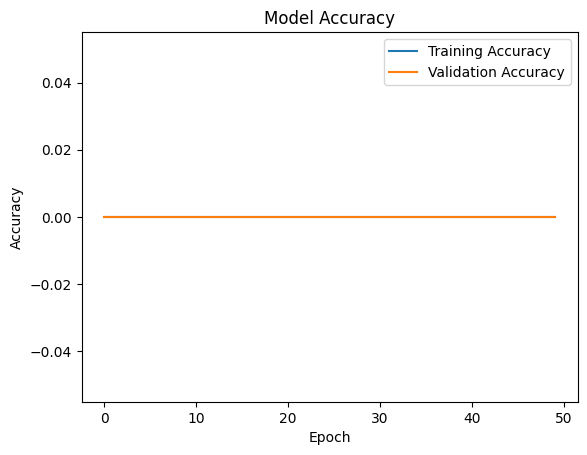

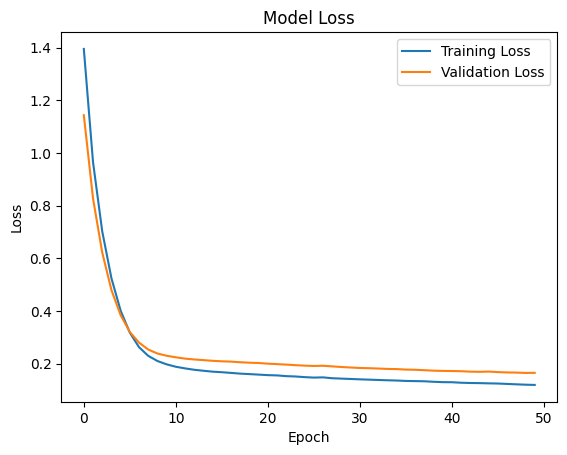

In [ ]:


import matplotlib.pyplot as plt


# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [ ]:
print(X_train.shape[0])

1004


In [ ]:
# prompt: generate forward pass for the test data with learned weights and save it as y_pred, I want to evaluate the accuracy based on the y_test .

# Generate predictions for the test data
y_pred = model.predict(X_test)

# Calculate the absolute percentage error
# Add a small epsilon to the denominator to avoid division by zero
epsilon = 1e-8
absolute_percentage_error = abs(y_test - y_pred) / (y_test + epsilon)

# Calculate the mean percentage error
mean_percentage_error = absolute_percentage_error.mean()

# Calculate 1 - mean percentage error
result = 1 - mean_percentage_error

print(f"Mean Percentage Error: {mean_percentage_error:.4f}")
print(f"1 - Mean Percentage Error: {result:.4f}")




14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Mean Percentage Error: 0.5622
1 - Mean Percentage Error: 0.4378


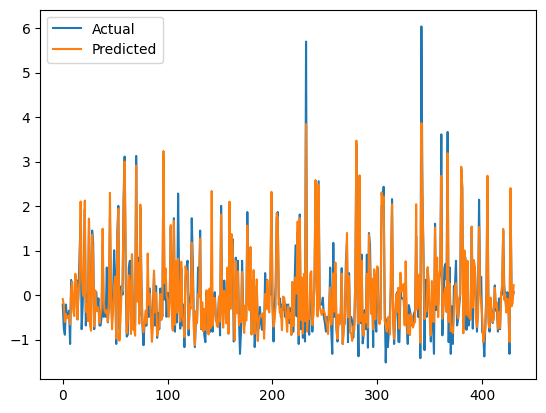

In [ ]:
plt.plot(y_test), label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()